In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

In [3]:
data = pd.read_csv('car-mpg.csv')
data

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
387,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
388,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
389,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
390,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


In [5]:
x= data[['mpg','horsepower']]
x

,mpg,horsepower
0,18.0,130.0
1,15.0,165.0
2,18.0,150.0
3,16.0,150.0
4,17.0,140.0
...,...,...
387,27.0,86.0
388,44.0,52.0
389,32.0,84.0
390,28.0,79.0


In [7]:
kmeans=KMeans()

In [8]:
wcss =[]

# Create all possible cluster solutions with a loop
# We have chosen to get solutions from 1 to 9 clusters; you can ammend that if you wish
for i in range(1,10):
    # Clsuter solution with i clusters
    kmeans = KMeans(i)
    # Fit the STANDARDIZED data
    kmeans.fit(x)
    # Append the WCSS for the iteration
    wcss.append(kmeans.inertia_)
    
# Check the result
wcss

E:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than availabl

[603112.6261224491,
 165292.3714613317,
 112433.6845306351,
 53276.65530683652,
 41576.90315765946,
 32794.33792791073,
 22674.554449194628,
 19048.844301448757,
 16441.954067202263]

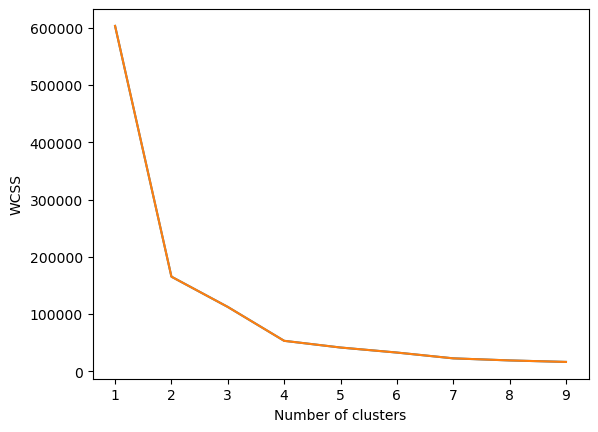

In [10]:
plt.plot(range(1,10),wcss)

# Name your axes
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [78]:
kmeans=KMeans(5)

In [79]:
x_new = x.copy()
x_new['clusters']=kmeans.fit_predict(x)

E:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [80]:
x_new.head()

,mpg,horsepower,clusters
0,18.0,130.0,1
1,15.0,165.0,4
2,18.0,150.0,1
3,16.0,150.0,1
4,17.0,140.0,1


In [81]:
kmeans.labels_

array([1, 4, 1, 1, 1, 3, 3, 3, 3, 4, 4, 4, 1, 3, 0, 0, 0, 0, 0, 2, 0, 0,
       0, 0, 0, 3, 3, 3, 4, 0, 0, 0, 0, 0, 0, 0, 0, 4, 4, 1, 1, 4, 4, 4,
       0, 2, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 0, 2, 2, 0, 0, 4, 4, 1, 1, 1,
       3, 1, 4, 4, 0, 1, 1, 1, 1, 0, 2, 0, 2, 0, 0, 0, 2, 0, 4, 1, 1, 1,
       1, 3, 1, 1, 1, 3, 3, 4, 0, 0, 0, 0, 0, 2, 1, 4, 4, 4, 0, 0, 2, 0,
       0, 0, 0, 0, 1, 3, 2, 2, 0, 0, 1, 0, 1, 4, 0, 0, 0, 2, 2, 2, 2, 0,
       0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2, 0, 0, 2, 2,
       4, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 2, 0, 2, 0, 0, 2, 0, 0,
       0, 0, 0, 2, 0, 2, 0, 2, 2, 1, 1, 1, 1, 0, 0, 2, 0, 2, 2, 2, 2, 0,
       2, 0, 0, 2, 2, 2, 2, 0, 1, 0, 0, 1, 4, 1, 1, 1, 2, 2, 2, 0, 2, 1,
       0, 1, 1, 0, 0, 0, 0, 4, 4, 4, 1, 2, 0, 2, 0, 2, 2, 2, 2, 0, 0, 0,
       2, 2, 2, 2, 2, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 4, 1, 1,
       2, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 1, 2, 2, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 1, 2, 0, 2, 2,

In [82]:
kmeans.cluster_centers_

array([[ 22.6221519 ,  96.94303797],
       [ 15.89090909, 142.09090909],
       [ 31.35271318,  69.28682171],
       [ 12.76923077, 214.15384615],
       [ 13.73846154, 174.42307692]])

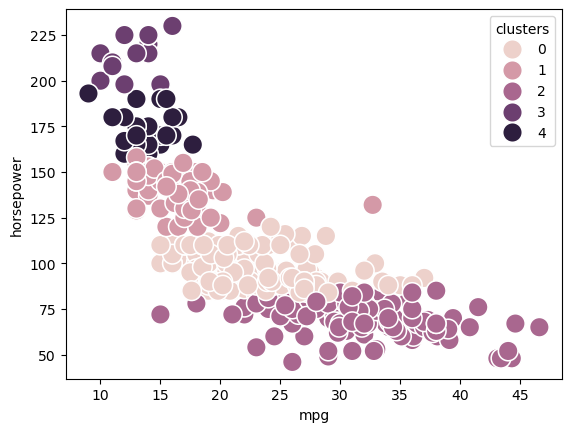

In [83]:
sns.scatterplot(data=x_new , x='mpg',y='horsepower',hue='clusters',s=200)
plt.xlabel('mpg')
plt.ylabel('horsepower')
plt.show()

In [84]:
from sklearn.metrics import silhouette_score

In [85]:
print(silhouette_score(x,kmeans.fit_predict(x)))

0.5017501073444997


E:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [86]:
import scipy.cluster.hierarchy as sch

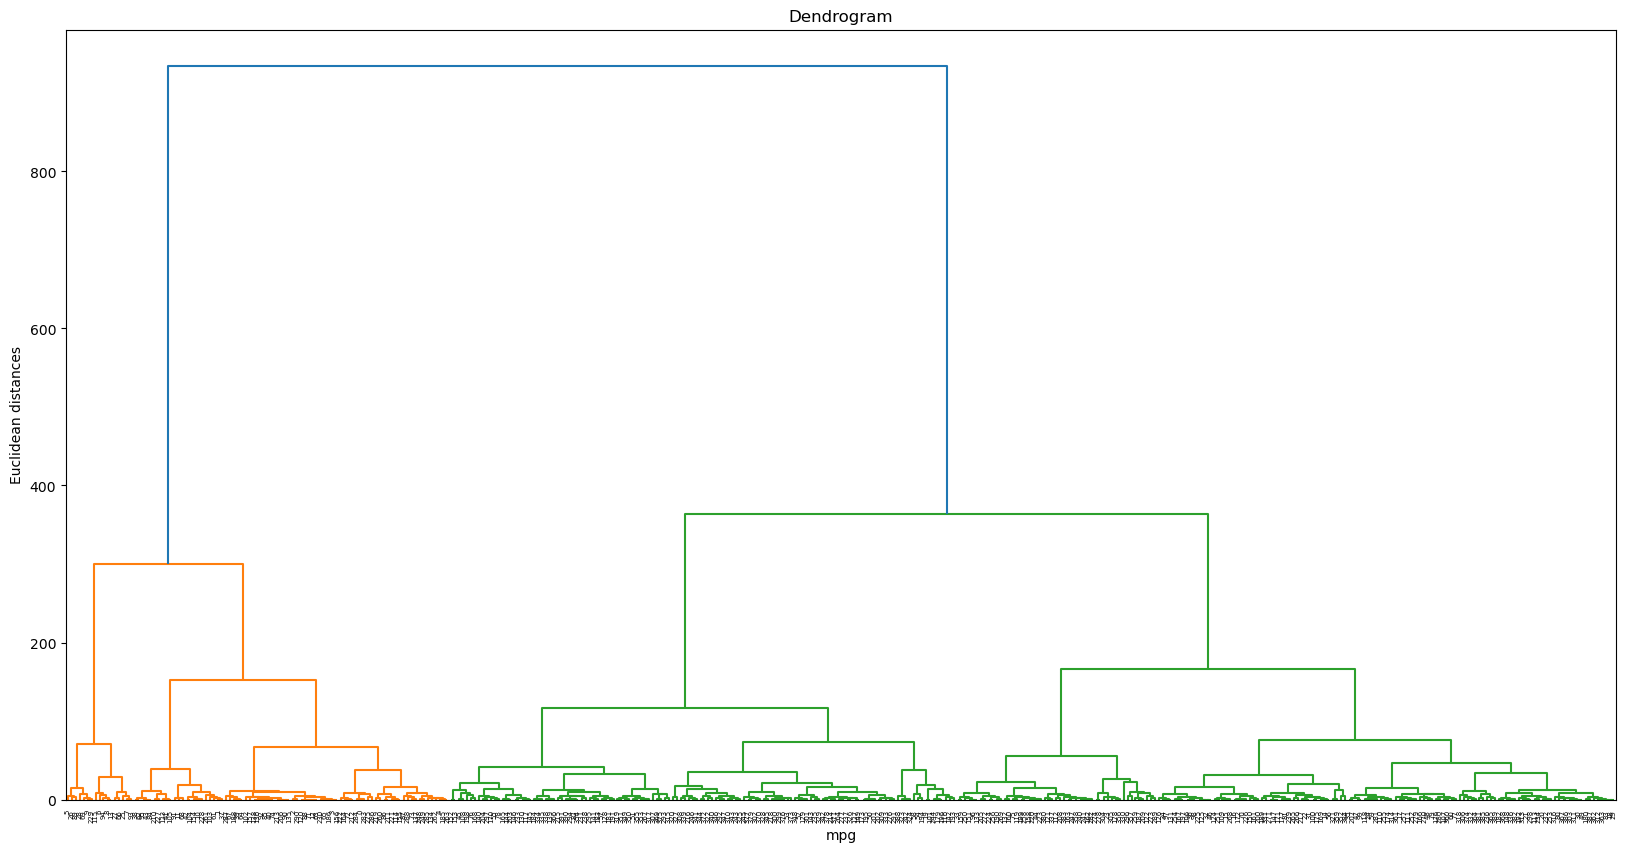

In [96]:
plt.figure(figsize=(20,10))
dendrogram = sch.dendrogram(sch.linkage(x, method = 'ward'))
plt.title('Dendrogram')
plt.xlabel('mpg')
plt.ylabel('Euclidean distances')
plt.show()

In [97]:
from sklearn.cluster import AgglomerativeClustering

In [102]:
model=AgglomerativeClustering(n_clusters=5)

In [103]:
model.fit(x)

AgglomerativeClustering(n_clusters=5)

In [104]:
model.fit_predict(x)

array([0, 0, 0, 0, 0, 3, 3, 3, 3, 3, 0, 0, 0, 3, 1, 1, 1, 1, 1, 2, 1, 1,
       1, 4, 1, 3, 3, 3, 3, 1, 1, 1, 1, 4, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       4, 2, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 1, 1, 0, 0, 0, 0, 0,
       3, 0, 0, 3, 1, 0, 0, 0, 0, 4, 2, 1, 2, 1, 1, 1, 2, 1, 0, 0, 0, 0,
       0, 3, 0, 0, 0, 3, 3, 0, 4, 1, 1, 1, 1, 2, 0, 0, 0, 0, 1, 1, 2, 1,
       1, 1, 4, 1, 0, 3, 2, 2, 1, 4, 0, 4, 4, 0, 1, 1, 1, 2, 2, 2, 2, 1,
       4, 4, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2, 1, 4, 2, 2,
       0, 0, 0, 0, 4, 4, 4, 1, 4, 4, 0, 2, 1, 1, 2, 1, 2, 1, 1, 2, 1, 1,
       1, 1, 4, 2, 1, 2, 1, 2, 2, 0, 0, 4, 0, 1, 4, 2, 1, 2, 2, 2, 2, 1,
       2, 4, 1, 2, 2, 2, 2, 4, 0, 1, 4, 4, 0, 0, 0, 0, 2, 2, 2, 1, 2, 0,
       4, 0, 0, 4, 4, 1, 1, 0, 0, 3, 0, 2, 1, 2, 1, 2, 1, 2, 2, 1, 4, 4,
       2, 2, 2, 2, 2, 4, 0, 0, 4, 1, 1, 1, 1, 1, 4, 1, 4, 4, 0, 0, 0, 0,
       2, 1, 1, 2, 1, 4, 1, 1, 4, 4, 4, 0, 2, 2, 4, 1, 1, 1, 4, 0, 0, 0,
       0, 0, 0, 4, 0, 2, 2, 2, 2, 2, 4, 2, 1, 2, 2,

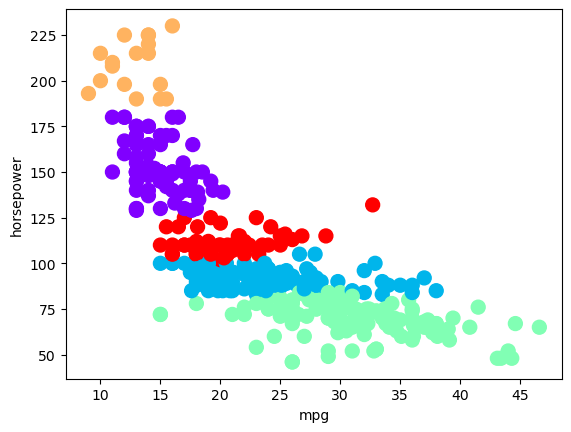

In [106]:
sns.scatterplot(data=x_new , x='mpg',y='horsepower',hue=model.labels_,s=200)
plt.xlabel('mpg')
plt.ylabel('horsepower')
plt.show()